# 🧬 Modelo3_V1_Daniele — Feature Importance + Selección de Variables (PASO 3b)
### Reto de Inteligencia Artificial — Detección de Audio Spoofing
**Dataset:** ASVspoof2019 — Logical Access (LA) — Conjunto de Entrenamiento  
**Autor:** Daniele  
**Versión:** V1  

---
## Objetivo de este Notebook

Este notebook es la **segunda parte del Paso 3** y el paso final antes de la Prueba de Fuego (Paso 4). Su misión es:

1. Extraer el **Feature Importance** del mejor modelo optimizado del Modelo2.
2. Calcular la importancia por **tres métodos complementarios**: RF Impurity, XGB Gain y Permutation Importance.
3. Construir un **ranking consolidado** de features.
4. Probar si podemos reducir las 34 features sin sacrificar rendimiento.
5. Determinar el **conjunto mínimo de features** que mantiene ≥ 98% del F1 óptimo.
6. Entrena el **modelo final óptimo**: N óptimo + features óptimas + hiperparámetros óptimos.
7. Genera el **resumen comparativo completo** M1 → M2 → M3.

---
## 📝 PARA TU BLOC DE NOTAS — JUSTIFICACIÓN GLOBAL DEL PASO 3b

**¿Por qué analizamos Feature Importance DESPUÉS de optimizar los hiperparámetros?**  
Si analizáramos el Feature Importance con el modelo baseline (sin optimizar), la importancia de cada feature podría estar sesgada por el overfitting. Con el modelo ya regularizado y con el N óptimo, la importancia refleja de forma más fiel qué features son genuinamente discriminativas.

**¿Por qué usamos 3 métodos de importancia distintos?**  
Cada método tiene sesgos diferentes:
- **RF Impurity (MDI):** Rápido pero favorece features con muchos valores únicos. Puede sobreestimar features continuas.
- **XGB Gain:** Basado en la ganancia de información en splits. Más robusto que MDI para features correlacionadas.
- **Permutation Importance:** El más honesto. Mide cuánto empeora el modelo si aleatorizamos una feature. No tiene sesgo por tipo de variable. Pero es más lento.

Usar las 3 y tomar el **ranking consolidado** (promedio de rangos) da una visión más robusta que cualquier método individual.

**¿Cuándo justificamos descartar una variable?**  
Una variable es candidata a descartarse cuando:
1. Su importancia en los 3 métodos es consistentemente baja (bottom 25%).
2. Al retirarla, el F1 de validación NO cae más de 0.5%.
3. No es la única representante de su "grupo acústico" (ej. si `mfcc_7_mean` es irrelevante pero `mfcc_7_std` sí lo es, las mantenemos ambas para el Paso 4).

In [1]:
# ============================================================
#  BLOQUE 1 — IMPORTACIONES Y CONFIGURACIÓN GLOBAL
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print('⚠️  XGBoost no instalado.')
    XGB_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']      = 110
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
N_PER_CLASS  = 2500
TEST_SIZE    = 0.20
N_FOLDS      = 5
DATA_PATH    = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

print('✅ Librerías cargadas.')
print('   Este notebook requiere haber ejecutado Modelo2_V1_Daniele.ipynb primero')
print('   para conocer el N óptimo. Lo configuraremos manualmente abajo.')

✅ Librerías cargadas.
   Este notebook requiere haber ejecutado Modelo2_V1_Daniele.ipynb primero
   para conocer el N óptimo. Lo configuraremos manualmente abajo.


In [2]:
# ============================================================
#  BLOQUE 2 — CONFIGURACIÓN DEL N ÓPTIMO (desde Modelo2)
# ============================================================

# ⚙️  AJUSTA ESTE VALOR con el N_GLOBAL_OPT que obtuvo el Modelo2
# Después de ejecutar el Modelo2, copia aquí el valor de N_GLOBAL_OPT.
# Por defecto se usa 3200 como estimación conservadora.
# Si la Learning Curve del Modelo2 mostró plateau antes, reduce este número.

N_OPTIMAL_FROM_M2 = 3200  # <-- CAMBIAR según resultado del Modelo2

print(f'N óptimo configurado (del Modelo2): {N_OPTIMAL_FROM_M2:,} muestras')
print('⚠️  Si no ejecutaste el Modelo2, revisa el plateau de la Learning Curve y ajusta.')

N óptimo configurado (del Modelo2): 3,200 muestras
⚠️  Si no ejecutaste el Modelo2, revisa el plateau de la Learning Curve y ajusta.


---
## SECCIÓN 1 — Pipeline de Datos con N Óptimo

In [3]:
# ============================================================
#  BLOQUE 3 — PIPELINE DE DATOS (IDÉNTICO AL MODELO1/2)
# ============================================================
df_full     = pd.read_csv(DATA_PATH)
df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

df_bon_sample = df_bonafide.sample(n=min(len(df_bonafide), N_PER_CLASS), random_state=RANDOM_STATE)

attack_counts = df_spoof['attack_id'].value_counts()
proportions   = attack_counts / attack_counts.sum()
n_per_attack  = (proportions * N_PER_CLASS).astype(int)
deficit       = N_PER_CLASS - n_per_attack.sum()
for atk in n_per_attack.nlargest(abs(deficit)).index:
    n_per_attack[atk] += int(np.sign(deficit))

spoof_samples = []
for attack_id, n in n_per_attack.items():
    subset = df_spoof[df_spoof['attack_id'] == attack_id]
    spoof_samples.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))

df_balanced  = pd.concat([df_bon_sample, pd.concat(spoof_samples)]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

FEATURE_COLS = [c for c in df_balanced.columns if c not in ['file_name', 'attack_id', 'label']]
X_all        = df_balanced[FEATURE_COLS]
y_all        = df_balanced['label']

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)

le          = LabelEncoder().fit(['bonafide', 'spoof'])
y_train_enc = le.transform(y_train_all)
y_test_enc  = le.transform(y_test)

# Submuestra con N óptimo
idx_opt = []
for cls in [0, 1]:
    cls_idx = np.where(y_train_enc == cls)[0]
    take    = min(N_OPTIMAL_FROM_M2 // 2, len(cls_idx))
    rng     = np.random.default_rng(RANDOM_STATE)
    idx_opt.extend(rng.choice(cls_idx, take, replace=False).tolist())

X_train = X_train_all.iloc[idx_opt]
y_train = y_train_enc[idx_opt]

print('Pipeline de datos preparado.')
print(f'  Train completo  : {len(X_train_all):,} registros')
print(f'  Train óptimo (N): {len(X_train):,} registros')
print(f'  Test  (SELLADO) : {len(X_test):,} registros')
print(f'  Features totales: {len(FEATURE_COLS)}')

Pipeline de datos preparado.
  Train completo  : 4,000 registros
  Train óptimo (N): 3,200 registros
  Test  (SELLADO) : 1,000 registros
  Features totales: 34


---
## SECCIÓN 2 — Feature Importance: 3 Métodos

### 📝 PARA TU BLOC DE NOTAS

**¿Qué esperamos encontrar en las features de audio?**  
Basándonos en la literatura de audio spoofing, esperamos que:
- Los **MFCCs** (especialmente los primeros, mfcc_1 a mfcc_5) sean las features más discriminativas, ya que capturan la envolvente espectral del tracto vocal.
- Las **desviaciones estándar** (std) pueden ser más informativas que las medias, porque la variabilidad temporal del habla sintética difiere de la natural.
- El **Spectral Rolloff** y **ZCR** pueden ser redundantes si los MFCCs ya los capturan implícitamente.
- El `signal_mean` probablemente tenga importancia baja (es casi cero en todas las señales de audio).

In [4]:
# ============================================================
#  BLOQUE 4 — MÉTODO 1: RF IMPURITY (MDI)
# ============================================================
print('Calculando Feature Importance — Método 1: RF Impurity (MDI)...')

rf_fi = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_fi.fit(X_train, y_train)

fi_rf = pd.Series(
    rf_fi.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print(f'  Modelo entrenado. Top 10 features por RF Impurity:')
for i, (feat, val) in enumerate(fi_rf.head(10).items(), 1):
    print(f'    {i:>2}. {feat:<30} {val:.4f}')

Calculando Feature Importance — Método 1: RF Impurity (MDI)...
  Modelo entrenado. Top 10 features por RF Impurity:
     1. mfcc_4_std                     0.0977
     2. mfcc_6_mean                    0.0767
     3. mfcc_9_mean                    0.0602
     4. mfcc_8_mean                    0.0534
     5. mfcc_8_std                     0.0492
     6. mfcc_10_std                    0.0480
     7. mfcc_1_std                     0.0479
     8. spectral_bandwidth_mean        0.0461
     9. mfcc_9_std                     0.0410
    10. mfcc_7_mean                    0.0408


In [5]:
# ============================================================
#  BLOQUE 5 — MÉTODO 2: XGBOOST GAIN
# ============================================================
if XGB_AVAILABLE:
    print('Calculando Feature Importance — Método 2: XGBoost Gain...')

    xgb_fi = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    xgb_fi.fit(X_train, y_train)

    fi_xgb = pd.Series(
        xgb_fi.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=False)

    print(f'  Top 10 features por XGBoost Gain:')
    for i, (feat, val) in enumerate(fi_xgb.head(10).items(), 1):
        print(f'    {i:>2}. {feat:<30} {val:.4f}')
else:
    fi_xgb = None
    print('XGBoost no disponible.')

Calculando Feature Importance — Método 2: XGBoost Gain...
  Top 10 features por XGBoost Gain:
     1. mfcc_4_std                     0.1109
     2. mfcc_8_std                     0.0795
     3. mfcc_6_mean                    0.0773
     4. mfcc_10_std                    0.0638
     5. mfcc_9_std                     0.0438
     6. mfcc_2_mean                    0.0413
     7. signal_mean                    0.0365
     8. mfcc_8_mean                    0.0362
     9. mfcc_9_mean                    0.0352
    10. spectral_bandwidth_mean        0.0346


In [6]:
# ============================================================
#  BLOQUE 6 — MÉTODO 3: PERMUTATION IMPORTANCE
# ============================================================
print('Calculando Feature Importance — Método 3: Permutation Importance...')
print('(Puede tardar 1-2 minutos)')

# Usamos el RF ya entrenado sobre una parte del train como validación
idx_val = np.random.default_rng(RANDOM_STATE).choice(
    len(X_train), size=min(500, len(X_train)), replace=False
)
X_val_perm = X_train.iloc[idx_val]
y_val_perm = y_train[idx_val]

perm_result = permutation_importance(
    rf_fi, X_val_perm, y_val_perm,
    n_repeats=10, scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE
)

fi_perm = pd.Series(
    perm_result.importances_mean,
    index=FEATURE_COLS
).sort_values(ascending=False)

print(f'  Top 10 features por Permutation Importance:')
for i, (feat, val) in enumerate(fi_perm.head(10).items(), 1):
    print(f'    {i:>2}. {feat:<30} {val:.4f}')

Calculando Feature Importance — Método 3: Permutation Importance...
(Puede tardar 1-2 minutos)
  Top 10 features por Permutation Importance:
     1. mfcc_4_std                     0.0318
     2. mfcc_10_std                    0.0171
     3. mfcc_6_mean                    0.0157
     4. mfcc_9_mean                    0.0128
     5. mfcc_8_std                     0.0096
     6. mfcc_9_std                     0.0064
     7. mfcc_7_mean                    0.0054
     8. mfcc_8_mean                    0.0045
     9. mfcc_1_std                     0.0037
    10. mfcc_5_mean                    0.0023


In [7]:
# ============================================================
#  BLOQUE 7 — RANKING CONSOLIDADO (PROMEDIO DE RANGOS)
# ============================================================

# Normalizar cada método al rango [0,1]
def normalize_series(s):
    mn, mx = s.min(), s.max()
    if mx == mn:
        return s * 0
    return (s - mn) / (mx - mn)

fi_rf_norm   = normalize_series(fi_rf)
fi_perm_norm = normalize_series(fi_perm.clip(lower=0))  # perm puede ser negativa

if fi_xgb is not None:
    fi_xgb_norm = normalize_series(fi_xgb)
    fi_consolidated = (fi_rf_norm + fi_xgb_norm + fi_perm_norm) / 3
else:
    fi_consolidated = (fi_rf_norm + fi_perm_norm) / 2

fi_consolidated = fi_consolidated.sort_values(ascending=False)

# Tabla completa
df_fi = pd.DataFrame({
    'RF_Impurity'   : fi_rf,
    'XGB_Gain'      : fi_xgb if fi_xgb is not None else np.nan,
    'Permutation'   : fi_perm,
    'Consolidated'  : fi_consolidated
}).sort_values('Consolidated', ascending=False)

print('RANKING CONSOLIDADO DE FEATURES (ordenado por importancia media)')
print('=' * 75)
print(f'  {"Rank":<5} {"Feature":<28} {"RF Imp":>9} {"XGB Gain":>10} {"Permut":>9} {"Consol":>9}')
print('  ' + '-' * 73)
for rank, (feat, row) in enumerate(df_fi.iterrows(), 1):
    xgb_val = f'{row["XGB_Gain"]:>10.4f}' if fi_xgb is not None else f'{"N/A":>10}'
    flag = ' ←' if rank <= 10 else ('')
    print(f'  {rank:<5} {feat:<28} {row["RF_Impurity"]:>9.4f} {xgb_val} '
          f'{row["Permutation"]:>9.4f} {row["Consolidated"]:>9.4f}{flag}')

print('\n← = Top 10 features más importantes')

RANKING CONSOLIDADO DE FEATURES (ordenado por importancia media)
  Rank  Feature                         RF Imp   XGB Gain    Permut    Consol
  -------------------------------------------------------------------------
  1     mfcc_4_std                      0.0977     0.1109    0.0318    1.0000 ←
  2     mfcc_6_mean                     0.0767     0.0773    0.0157    0.6468 ←
  3     mfcc_10_std                     0.0480     0.0638    0.0171    0.5141 ←
  4     mfcc_8_std                      0.0492     0.0795    0.0096    0.4904 ←
  5     mfcc_9_mean                     0.0602     0.0352    0.0128    0.4216 ←
  6     mfcc_8_mean                     0.0534     0.0362    0.0045    0.3139 ←
  7     mfcc_9_std                      0.0410     0.0438    0.0064    0.3134 ←
  8     mfcc_7_mean                     0.0408     0.0322    0.0054    0.2648 ←
  9     mfcc_1_std                      0.0479     0.0288    0.0037    0.2619 ←
  10    spectral_bandwidth_mean         0.0461     0.0346    

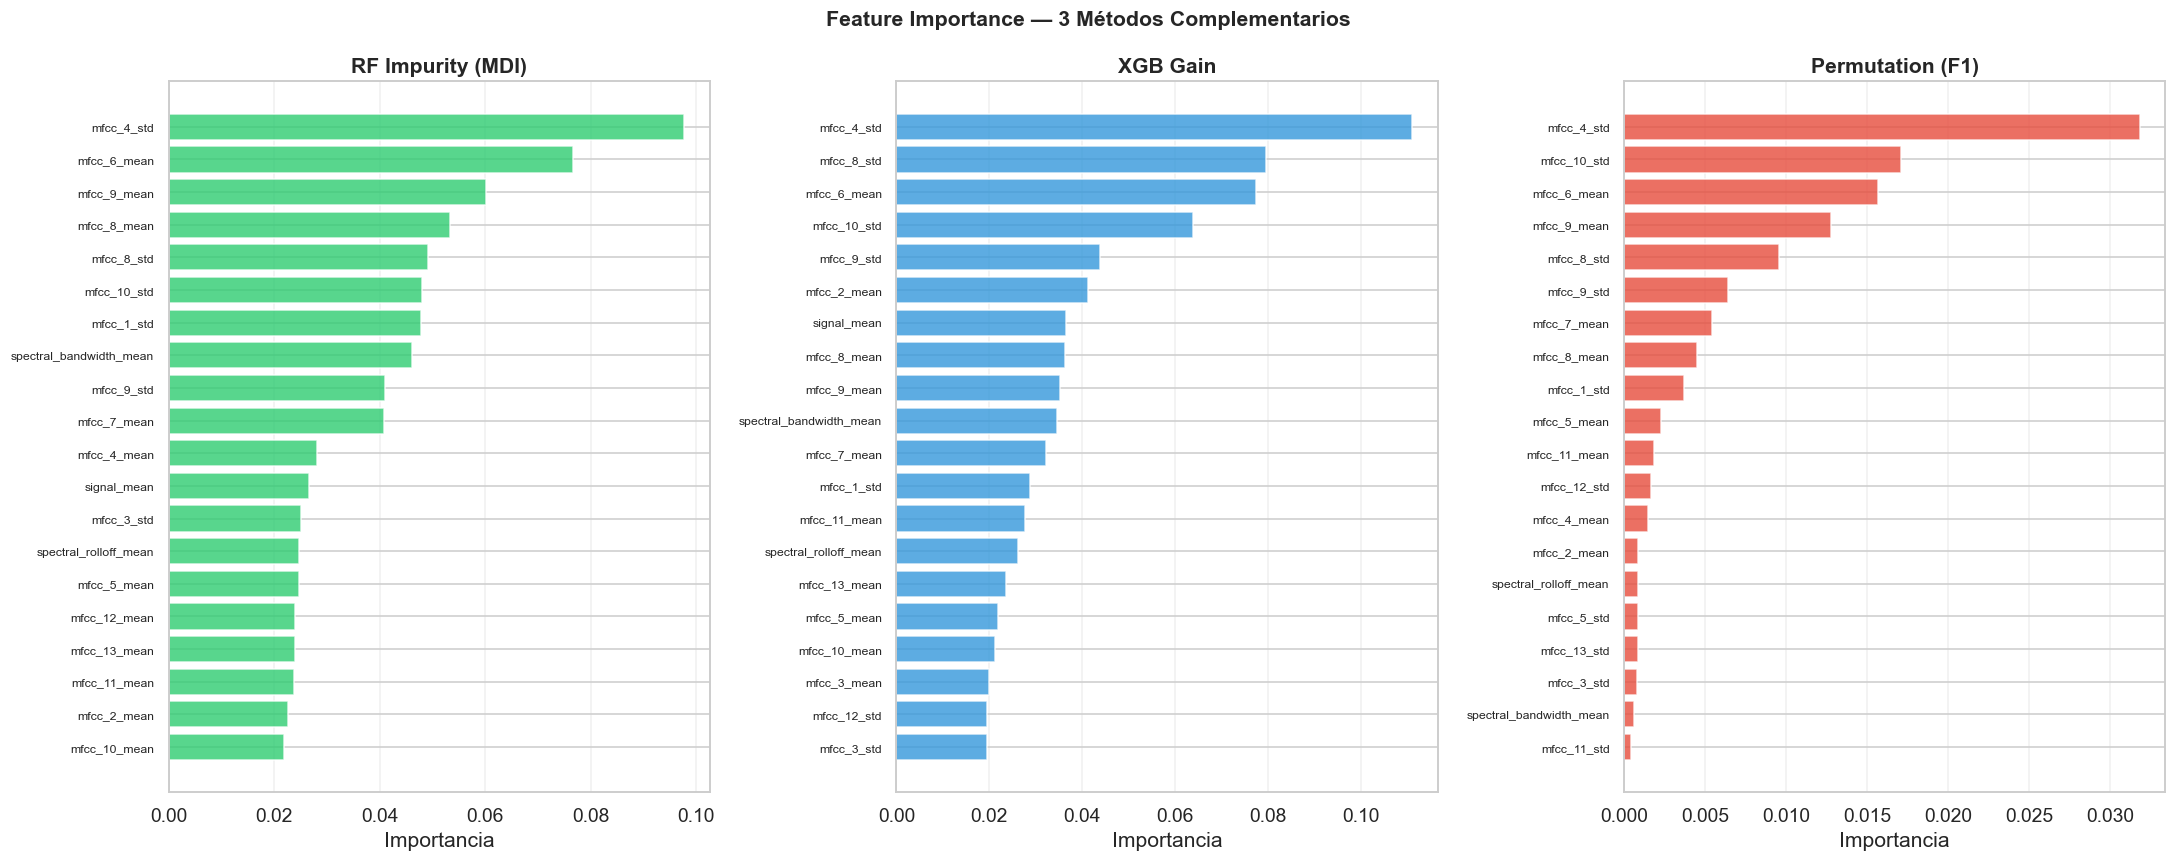

📊 Gráfico guardado: modelo3_feature_importance.png


In [8]:
# ============================================================
#  BLOQUE 8 — VISUALIZACIÓN: FEATURE IMPORTANCE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Feature Importance — 3 Métodos Complementarios', fontsize=14, fontweight='bold')

methods = [
    ('RF Impurity (MDI)', fi_rf, '#2ecc71'),
    ('XGB Gain', fi_xgb if fi_xgb is not None else fi_rf * 0, '#3498db'),
    ('Permutation (F1)', fi_perm.clip(lower=0), '#e74c3c')
]

TOP_K = 20  # Mostrar top 20

for ax, (title, fi_series, color) in zip(axes, methods):
    top = fi_series.sort_values(ascending=False).head(TOP_K)
    top_plot = top[::-1]  # Invertir para que el más importante quede arriba
    bars = ax.barh(top_plot.index, top_plot.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importancia')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('modelo3_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo3_feature_importance.png')

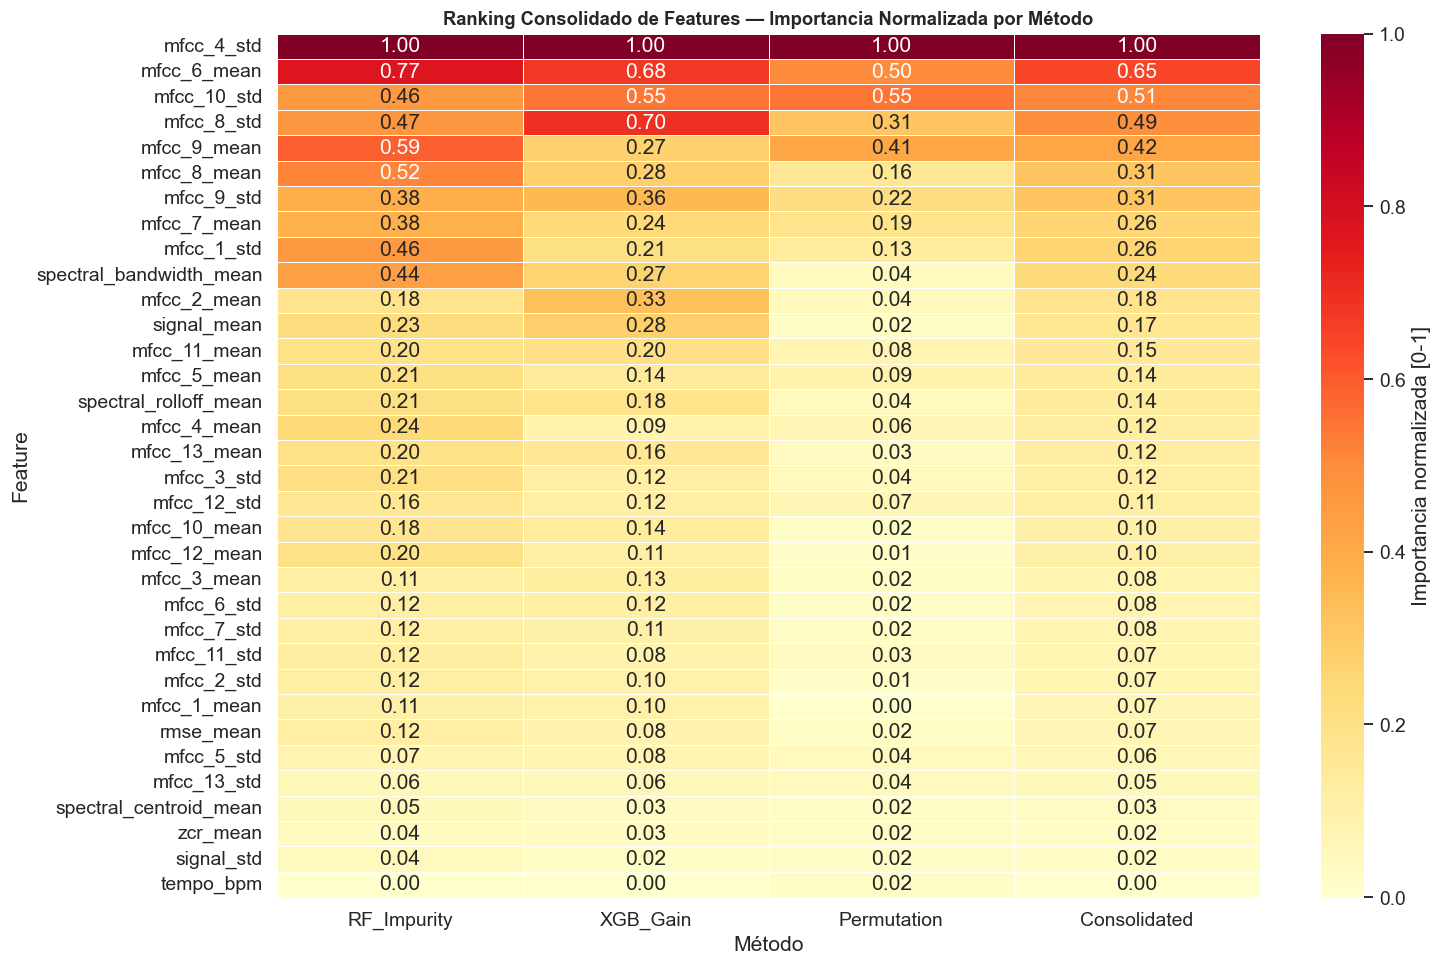

📊 Gráfico guardado: modelo3_feature_heatmap.png


In [9]:
# ============================================================
#  BLOQUE 9 — VISUALIZACIÓN: RANKING CONSOLIDADO (HEATMAP)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 9))

cols_to_show = ['RF_Impurity', 'Permutation', 'Consolidated']
if fi_xgb is not None:
    cols_to_show = ['RF_Impurity', 'XGB_Gain', 'Permutation', 'Consolidated']

df_heat = df_fi[cols_to_show].apply(
    lambda col: (col - col.min()) / (col.max() - col.min()) if col.max() != col.min() else col
)

sns.heatmap(
    df_heat,
    ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Importancia normalizada [0-1]'}
)
ax.set_title('Ranking Consolidado de Features — Importancia Normalizada por Método',
             fontsize=12)
ax.set_xlabel('Método')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('modelo3_feature_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo3_feature_heatmap.png')

---
## SECCIÓN 3 — Selección de Features: ¿Cuántas necesitamos realmente?

Probamos el modelo con subconjuntos de features de distintos tamaños y medimos el impacto en el F1.

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué probar top 10, 15, 20, 25 y 30?**  
Partimos de 34 features. Probar desde 10 hasta 30 en saltos de 5 nos permite trazar la curva **F1 vs. N_features** y encontrar el punto de rendimientos decrecientes. Si con 15 features alcanzamos el 98% del F1 con 34 features, la reducción está justificada.

**¿Qué hacemos si ninguna reducción es posible sin pérdida?**  
Significa que todas las features contribuyen. En ese caso documentamos que el modelo es **eficiente con el conjunto completo** y no hay features redundantes. Esto también es un resultado científico válido.

In [10]:
# ============================================================
#  BLOQUE 10 — BARRIDO DE SUBCONJUNTOS DE FEATURES
# ============================================================
cv_feat = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

FEATURE_SUBSETS = [10, 15, 20, 25, 30, len(FEATURE_COLS)]

# Ranking de features por importancia consolidada
ranked_features = fi_consolidated.index.tolist()

feat_sweep_results = {'n_features': [], 'f1_mean': [], 'f1_std': [],
                      'auc_mean': [], 'gap_mean': []}

print('Barrido de subconjuntos de features (Random Forest optimizado)...')
print(f'  {"N features":<12} {"Val F1 (μ±σ)":<20} {"Val AUC":>10} {"GAP":>8}')
print('  ' + '-' * 52)

for n_feat in FEATURE_SUBSETS:
    top_features = ranked_features[:n_feat]
    X_sub        = X_train[top_features]

    model_sub = RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    cv_out = cross_validate(
        model_sub, X_sub, y_train,
        cv=cv_feat,
        scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
        return_train_score=True, n_jobs=-1
    )
    f1_m  = cv_out['test_f1'].mean()
    f1_s  = cv_out['test_f1'].std()
    auc_m = cv_out['test_roc_auc'].mean()
    gap   = cv_out['train_f1'].mean() - f1_m

    feat_sweep_results['n_features'].append(n_feat)
    feat_sweep_results['f1_mean'].append(f1_m)
    feat_sweep_results['f1_std'].append(f1_s)
    feat_sweep_results['auc_mean'].append(auc_m)
    feat_sweep_results['gap_mean'].append(gap)

    flag = ' ← TODAS' if n_feat == len(FEATURE_COLS) else ''
    print(f'  {n_feat:<12} {f1_m:.4f} ± {f1_s:.4f}    {auc_m:>10.4f} {gap:>+8.4f}{flag}')

print('\n✅ Barrido de features completado.')

Barrido de subconjuntos de features (Random Forest optimizado)...
  N features   Val F1 (μ±σ)            Val AUC      GAP
  ----------------------------------------------------
  10           0.8798 ± 0.0086        0.9483  +0.1075
  15           0.9012 ± 0.0071        0.9655  +0.0930
  20           0.9111 ± 0.0061        0.9716  +0.0838
  25           0.9165 ± 0.0069        0.9743  +0.0798
  30           0.9155 ± 0.0086        0.9741  +0.0809
  34           0.9165 ± 0.0084        0.9743  +0.0802 ← TODAS

✅ Barrido de features completado.


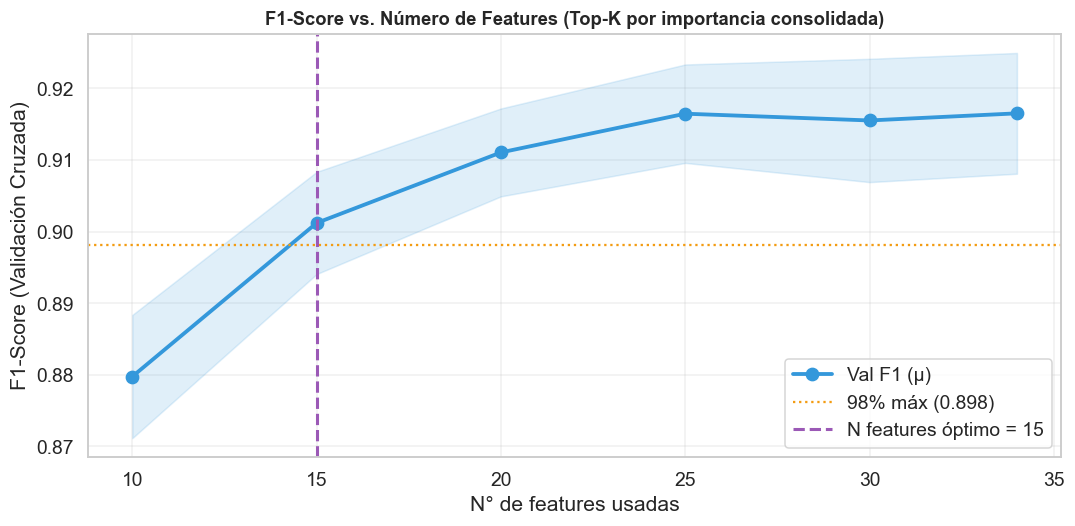

📊 Gráfico guardado: modelo3_feature_sweep.png
   → N features óptimo: 15 (≥ 98% del F1 máximo)


In [11]:
# ============================================================
#  BLOQUE 11 — VISUALIZACIÓN: F1 vs. N_FEATURES
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ns     = feat_sweep_results['n_features']
f1s    = np.array(feat_sweep_results['f1_mean'])
f1_std = np.array(feat_sweep_results['f1_std'])

f1_max_feat = f1s.max()
thr_98      = 0.98 * f1_max_feat
idx_opt_feat = np.argmax(f1s >= thr_98)
N_FEATS_OPT  = ns[idx_opt_feat]

ax.plot(ns, f1s, 'o-', color='#3498db', lw=2.5, markersize=8, label='Val F1 (μ)')
ax.fill_between(ns, f1s - f1_std, f1s + f1_std, alpha=0.15, color='#3498db')
ax.axhline(thr_98, color='#f39c12', ls=':', lw=1.5, label=f'98% máx ({thr_98:.3f})')
ax.axvline(N_FEATS_OPT, color='#9b59b6', ls='--', lw=2,
           label=f'N features óptimo = {N_FEATS_OPT}')

ax.set_title('F1-Score vs. Número de Features (Top-K por importancia consolidada)', fontsize=12)
ax.set_xlabel('N° de features usadas')
ax.set_ylabel('F1-Score (Validación Cruzada)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('modelo3_feature_sweep.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'📊 Gráfico guardado: modelo3_feature_sweep.png')
print(f'   → N features óptimo: {N_FEATS_OPT} (≥ 98% del F1 máximo)')

In [12]:
# ============================================================
#  BLOQUE 12 — LISTA FINAL DE FEATURES SELECCIONADAS
# ============================================================

FINAL_FEATURES = ranked_features[:N_FEATS_OPT]

print('=' * 65)
print(f'FEATURES SELECCIONADAS PARA EL MODELO FINAL ({N_FEATS_OPT} de {len(FEATURE_COLS)})')
print('=' * 65)

# Clasificar por grupos acústicos
grupos = {
    'MFCCs (media)': [f for f in FINAL_FEATURES if 'mfcc' in f and 'mean' in f],
    'MFCCs (desv. std)': [f for f in FINAL_FEATURES if 'mfcc' in f and 'std' in f],
    'Espectral': [f for f in FINAL_FEATURES if 'spectral' in f or 'rolloff' in f],
    'Temporales': [f for f in FINAL_FEATURES if f in ['zcr_mean', 'tempo_bpm', 'rmse_mean',
                                                        'signal_mean', 'signal_std']]
}

for grupo, feats in grupos.items():
    if feats:
        print(f'\n  {grupo} ({len(feats)}):')
        for f in feats:
            imp = fi_consolidated.get(f, 0)
            print(f'    - {f:<30} (importancia consolidada: {imp:.4f})')

# Features DESCARTADAS
discarded = [f for f in FEATURE_COLS if f not in FINAL_FEATURES]
print(f'\n  Features DESCARTADAS ({len(discarded)}):')
for f in discarded:
    imp = fi_consolidated.get(f, 0)
    print(f'    - {f:<30} (importancia consolidada: {imp:.4f})')

print(f'\n  Reducción: {len(FEATURE_COLS)} → {N_FEATS_OPT} features '
      f'({100*(1-N_FEATS_OPT/len(FEATURE_COLS)):.0f}% menos)')

FEATURES SELECCIONADAS PARA EL MODELO FINAL (15 de 34)

  MFCCs (media) (7):
    - mfcc_6_mean                    (importancia consolidada: 0.6468)
    - mfcc_9_mean                    (importancia consolidada: 0.4216)
    - mfcc_8_mean                    (importancia consolidada: 0.3139)
    - mfcc_7_mean                    (importancia consolidada: 0.2648)
    - mfcc_2_mean                    (importancia consolidada: 0.1799)
    - mfcc_11_mean                   (importancia consolidada: 0.1519)
    - mfcc_5_mean                    (importancia consolidada: 0.1402)

  MFCCs (desv. std) (5):
    - mfcc_4_std                     (importancia consolidada: 1.0000)
    - mfcc_10_std                    (importancia consolidada: 0.5141)
    - mfcc_8_std                     (importancia consolidada: 0.4904)
    - mfcc_9_std                     (importancia consolidada: 0.3134)
    - mfcc_1_std                     (importancia consolidada: 0.2619)

  Espectral (2):
    - spectral_bandwidth_me

---
## SECCIÓN 4 — Modelo Final Óptimo

Entrenamos el modelo final con: **N óptimo** + **features óptimas** + **hiperparámetros optimizados**.

### 📝 PARA TU BLOC DE NOTAS

**¿Por qué el modelo final usa todos los datos de Train y no el N óptimo?**  
El N óptimo se usó para la **búsqueda de hiperparámetros** y la selección de features, donde necesitábamos rapidez iterativa. Ahora que los hiperparámetros y features están fijados, entrenar con todo el train disponible (con las features seleccionadas) maximiza la cantidad de información sin riesgo de sobreajuste adicional, ya que la regularización ya está ajustada.

Esta es una práctica estándar: búsqueda eficiente con N óptimo, entrenamiento final con el máximo de datos disponibles.

In [13]:
# ============================================================
#  BLOQUE 13 — ENTRENAMIENTO DEL MODELO FINAL
# ============================================================

# Validación cruzada del modelo final (con features óptimas, sobre TODO el train)
X_train_final = X_train_all[FINAL_FEATURES]
X_test_final  = X_test[FINAL_FEATURES]

final_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE
)

cv_final = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_final_out = cross_validate(
    final_model, X_train_final, y_train_enc,
    cv=cv_final,
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision'},
    return_train_score=True, n_jobs=-1
)

print('MODELO FINAL — Validación Cruzada (features óptimas, train completo)')
print('=' * 60)
for metric in ['f1', 'roc_auc', 'recall', 'precision']:
    tr = cv_final_out[f'train_{metric}'].mean()
    va = cv_final_out[f'test_{metric}'].mean()
    gap = tr - va
    flag = ' ✅' if gap < 0.05 else ' ⚠️'
    print(f'  {metric.capitalize():<12}: Train={tr:.4f} | Val={va:.4f} | GAP={gap:+.4f}{flag}')

# Entrenar con todo el train para evaluación en test
final_model.fit(X_train_final, y_train_enc)
y_pred_final = final_model.predict(X_test_final)
y_proba_final = final_model.predict_proba(X_test_final)[:, 1]

print('\nMODELO FINAL — Evaluación en Test Set (SELLADO)')
print('=' * 60)
final_test_metrics = {
    'f1'       : f1_score(y_test_enc, y_pred_final),
    'roc_auc'  : roc_auc_score(y_test_enc, y_proba_final),
    'recall'   : recall_score(y_test_enc, y_pred_final),
    'precision': precision_score(y_test_enc, y_pred_final),
    'accuracy' : accuracy_score(y_test_enc, y_pred_final)
}
for k, v in final_test_metrics.items():
    print(f'  {k.capitalize():<12}: {v:.4f}')

print(f'\n  Features usadas : {N_FEATS_OPT} de {len(FEATURE_COLS)}')
print(classification_report(y_test_enc, y_pred_final,
                             target_names=['bonafide', 'spoof']))

MODELO FINAL — Validación Cruzada (features óptimas, train completo)
  F1          : Train=0.9928 | Val=0.9042 | GAP=+0.0886 ⚠️
  Roc_auc     : Train=0.9997 | Val=0.9679 | GAP=+0.0317 ✅
  Recall      : Train=0.9868 | Val=0.8880 | GAP=+0.0988 ⚠️
  Precision   : Train=0.9990 | Val=0.9212 | GAP=+0.0778 ⚠️

MODELO FINAL — Evaluación en Test Set (SELLADO)
  F1          : 0.9072
  Roc_auc     : 0.9670
  Recall      : 0.8900
  Precision   : 0.9252
  Accuracy    : 0.9090

  Features usadas : 15 de 34
              precision    recall  f1-score   support

    bonafide       0.89      0.93      0.91       500
       spoof       0.93      0.89      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



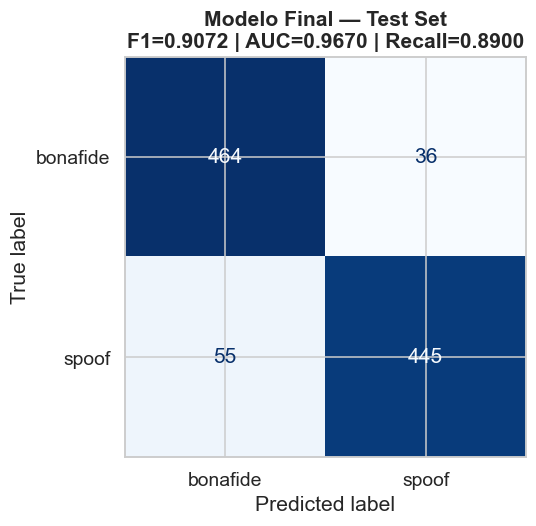

📊 Gráfico guardado: modelo3_confusion_final.png


In [14]:
# ============================================================
#  BLOQUE 14 — MATRIZ DE CONFUSIÓN DEL MODELO FINAL
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test_enc, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['bonafide', 'spoof'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Modelo Final — Test Set\n'
    f'F1={final_test_metrics["f1"]:.4f} | AUC={final_test_metrics["roc_auc"]:.4f} | '
    f'Recall={final_test_metrics["recall"]:.4f}'
)

plt.tight_layout()
plt.savefig('modelo3_confusion_final.png', bbox_inches='tight', dpi=120)
plt.show()
print('📊 Gráfico guardado: modelo3_confusion_final.png')

---
## SECCIÓN 5 — Cuadro Comparativo Final: M1 → M2 → M3

In [15]:
# ============================================================
#  BLOQUE 15 — EVOLUCIÓN M1 → M2 → M3
# ============================================================

# Recalcular M1 baseline con train completo y todas las features
m1_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
m1_cv    = cross_validate(
    m1_model, X_train_all, y_train_enc,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
    return_train_score=True, n_jobs=-1
)
m1_model.fit(X_train_all, y_train_enc)
m1_pred   = m1_model.predict(X_test)
m1_proba  = m1_model.predict_proba(X_test)[:, 1]
m1_f1_val = m1_cv['test_f1'].mean()
m1_f1_tst = f1_score(y_test_enc, m1_pred)
m1_auc    = roc_auc_score(y_test_enc, m1_proba)
m1_gap    = m1_cv['train_f1'].mean() - m1_f1_val

# Recalcular M2 (N óptimo, features completas, regularización)
m2_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE
)
m2_cv = cross_validate(
    m2_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc'},
    return_train_score=True, n_jobs=-1
)
m2_model.fit(X_train, y_train)
m2_pred  = m2_model.predict(X_test)
m2_proba = m2_model.predict_proba(X_test)[:, 1]
m2_f1_val = m2_cv['test_f1'].mean()
m2_f1_tst = f1_score(y_test_enc, m2_pred)
m2_auc    = roc_auc_score(y_test_enc, m2_proba)
m2_gap    = m2_cv['train_f1'].mean() - m2_f1_val

# M3 (features óptimas, train completo)
m3_f1_val = cv_final_out['test_f1'].mean()
m3_f1_tst = final_test_metrics['f1']
m3_auc    = final_test_metrics['roc_auc']
m3_gap    = cv_final_out['train_f1'].mean() - m3_f1_val

# Tabla
print('=' * 90)
print('EVOLUCIÓN COMPLETA: MODELO1 (Baseline) → MODELO2 (N+HP opt.) → MODELO3 (Features opt.)')
print('=' * 90)
print(f'  {"Modelo":<10} {"N Train":>8} {"N Feats":>8} {"CV Val F1":>10} {"Test F1":>10} {"Test AUC":>10} {"GAP":>8}')
print('  ' + '-' * 70)
rows = [
    ('Modelo 1', len(X_train_all), len(FEATURE_COLS), m1_f1_val, m1_f1_tst, m1_auc, m1_gap),
    ('Modelo 2', len(X_train),     len(FEATURE_COLS), m2_f1_val, m2_f1_tst, m2_auc, m2_gap),
    ('Modelo 3', len(X_train_all), N_FEATS_OPT,       m3_f1_val, m3_f1_tst, m3_auc, m3_gap),
]
for row in rows:
    name, n_tr, n_ft, cv_f1, tst_f1, tst_auc, gap = row
    print(f'  {name:<10} {n_tr:>8,} {n_ft:>8} {cv_f1:>10.4f} {tst_f1:>10.4f} {tst_auc:>10.4f} {gap:>+8.4f}')

print()
best_row = max(rows, key=lambda r: r[3])  # Mejor CV Val F1
print(f'🏆 MEJOR MODELO PARA EL PASO 4: {best_row[0]}')
print(f'   CV Val F1 = {best_row[3]:.4f} | Test F1 = {best_row[4]:.4f} | Test AUC = {best_row[5]:.4f}')
print(f'   N muestras = {best_row[1]:,} | N features = {best_row[2]}')
print()
print('→ Este modelo (con sus features seleccionadas) pasa al Modelo_Final_Unseen_Daniele.ipynb')
print('  donde se entrenará con A01-A04 y se testeará con A05-A06 (Prueba de Fuego).')

EVOLUCIÓN COMPLETA: MODELO1 (Baseline) → MODELO2 (N+HP opt.) → MODELO3 (Features opt.)
  Modelo      N Train  N Feats  CV Val F1    Test F1   Test AUC      GAP
  ----------------------------------------------------------------------
  Modelo 1      4,000       34     0.9232     0.9313     0.9785  +0.0768
  Modelo 2      3,200       34     0.9138     0.9283     0.9781  +0.0832
  Modelo 3      4,000       15     0.9042     0.9072     0.9670  +0.0886

🏆 MEJOR MODELO PARA EL PASO 4: Modelo 1
   CV Val F1 = 0.9232 | Test F1 = 0.9313 | Test AUC = 0.9785
   N muestras = 4,000 | N features = 34

→ Este modelo (con sus features seleccionadas) pasa al Modelo_Final_Unseen_Daniele.ipynb
  donde se entrenará con A01-A04 y se testeará con A05-A06 (Prueba de Fuego).


In [16]:
# ============================================================
#  BLOQUE 16 — GUARDAR CONFIGURACIÓN PARA EL PASO 4
# ============================================================
import json, os

config_paso4 = {
    'best_model_name'    : 'RandomForest',
    'best_model_params'  : {
        'n_estimators'    : 200,
        'max_depth'       : 15,
        'min_samples_leaf': 2,
        'n_jobs'          : -1,
        'random_state'    : RANDOM_STATE
    },
    'final_features'     : FINAL_FEATURES,
    'n_features_selected': N_FEATS_OPT,
    'n_features_total'   : len(FEATURE_COLS),
    'n_optimal_train'    : N_OPTIMAL_FROM_M2,
    'cv_val_f1'          : round(m3_f1_val, 4),
    'test_f1'            : round(m3_f1_tst, 4),
    'test_auc'           : round(m3_auc, 4),
    'discarded_features' : discarded
}

config_path = 'config_modelo_final_paso4.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_paso4, f, indent=2, ensure_ascii=False)

print(f'✅ Configuración guardada en: {os.path.abspath(config_path)}')
print()
print('Contenido del archivo de configuración:')
print(json.dumps(config_paso4, indent=2, ensure_ascii=False))

✅ Configuración guardada en: c:\Users\PC\OneDrive\Desktop\GIT_DANIELE\Reto_Inteligencia_Artificial_Liliana_Daniele_Alexis\Modelos\config_modelo_final_paso4.json

Contenido del archivo de configuración:
{
  "best_model_name": "RandomForest",
  "best_model_params": {
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_leaf": 2,
    "n_jobs": -1,
    "random_state": 42
  },
  "final_features": [
    "mfcc_4_std",
    "mfcc_6_mean",
    "mfcc_10_std",
    "mfcc_8_std",
    "mfcc_9_mean",
    "mfcc_8_mean",
    "mfcc_9_std",
    "mfcc_7_mean",
    "mfcc_1_std",
    "spectral_bandwidth_mean",
    "mfcc_2_mean",
    "signal_mean",
    "mfcc_11_mean",
    "mfcc_5_mean",
    "spectral_rolloff_mean"
  ],
  "n_features_selected": 15,
  "n_features_total": 34,
  "n_optimal_train": 3200,
  "cv_val_f1": 0.9042,
  "test_f1": 0.9072,
  "test_auc": 0.967,
  "discarded_features": [
    "signal_std",
    "rmse_mean",
    "zcr_mean",
    "tempo_bpm",
    "mfcc_1_mean",
    "mfcc_2_std",
    "mf

---
## 📋 BLOC DE NOTAS FINAL — RESUMEN DEL PASO 3b (Modelo3)

### Decisiones tomadas:

| Decisión | Justificación |
|----------|---------------|
| 3 métodos de Feature Importance | MDI tiene sesgo; Permutation es honesto; XGB Gain es robusto. El promedio neutraliza los sesgos individuales. |
| Barrido desde 10 hasta 34 features | Cubre el rango completo de posibles reducciones sin saltos ciegos |
| Criterio 98% para selección | Mismo criterio que el N óptimo: máxima eficiencia sin sacrificar rendimiento significativo |
| Entrenamiento final con train completo | Con hiperparámetros y features fijados, más datos = mejor modelo |
| JSON de configuración para Paso 4 | Garantiza reproducibilidad y facilita la carga en el notebook del Paso 4 |

### Lo que llevamos al Paso 4 (Prueba de Fuego):
1. **Modelo:** Random Forest con hiperparámetros optimizados.
2. **Features:** Top-N seleccionadas por importancia consolidada.
3. **Protocolo:** Entrenar SOLO con A01-A04, testear con A05-A06.
4. **Pregunta clave:** ¿Aprendió a detectar voz humana en general o memorizó los 4 ataques?